1.LOAD DATASET

In [1]:
import pandas as pd

PLATFORM = "Youtube"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/youtube_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/youtube_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(14504, 56)
(3626, 56)


In [2]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    11602
1     2902
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.991726
1    20.008274
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    2901
1     725
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    80.005516
1    19.994484
Name: proportion, dtype: float64


In [3]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [4]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Calculate class imbalance ratio
ratio = 11602 / 2902

# Initialize XGBoost with optimized parameters
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [5]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [6]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)

In [7]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [8]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=6
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0   0.925671  0.880041  0.902280      2901
           1   0.599078  0.717241  0.652856       725

    accuracy                       0.847490      3626
   macro avg   0.762375  0.798641  0.777568      3626
weighted avg   0.860370  0.847490  0.852409      3626



In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[2553  348]
 [ 205  520]]


In [10]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
3             followers    0.196894
5              verified    0.129989
21        topic_Climate    0.015768
18  sentiment_intensity    0.015383
10       toxicity_score    0.015348
52     location_Unknown    0.015214
30        topic_Science    0.015030
41  language_Portuguese    0.014825
25        topic_Finance    0.014775
44      media_type_Poll    0.014718
8    sentiment_positive    0.014676
27         topic_Gaming    0.014647
42     language_Spanish    0.014616
39    language_Japanese    0.014466
9    sentiment_negative    0.014256


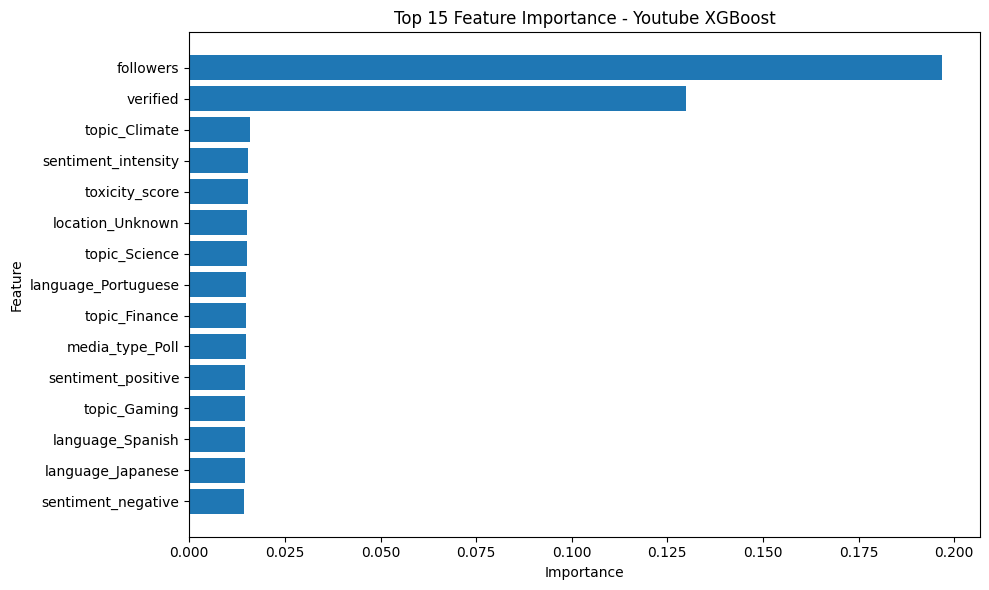

In [11]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Youtube XGBoost"
)

plt.tight_layout()

plt.show()